In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [ ]:
import torch

def symmetrize_neighbors_padded_fast(idx, mask, d, dx, pad_value=-1):
    device = idx.device
    N, m = idx.shape

    # 1️⃣ Build masked directed edges
    src = torch.arange(N, device=device).repeat_interleave(m)
    dst = idx.reshape(-1)
    mask_flat = mask.reshape(-1)
    d_flat = d.reshape(-1)
    dx_flat = dx.reshape(-1, 3)

    src = src[mask_flat]
    dst = dst[mask_flat]
    d_flat = d_flat[mask_flat]
    dx_flat = dx_flat[mask_flat]

    # 2️⃣ Symmetrize edges
    src_sym = torch.cat([src, dst], dim=0)
    dst_sym = torch.cat([dst, src], dim=0)
    d_sym = torch.cat([d_flat, d_flat], dim=0)
    dx_sym = torch.cat([dx_flat, -dx_flat], dim=0)
    edges = torch.stack([src_sym, dst_sym], dim=1)

    # 3️⃣ Remove self-loops
    keep = edges[:, 0] != edges[:, 1]
    edges = edges[keep]
    d_sym = d_sym[keep]
    dx_sym = dx_sym[keep]

    # 4️⃣ Deduplicate edges
    edges, unique_idx = torch.unique(edges, dim=0, return_inverse=False, return_counts=False,
                                     sorted=False, return_indices=True)
    d_sym = d_sym[unique_idx]
    dx_sym = dx_sym[unique_idx]

    # 5️⃣ Compute neighbor counts
    row = edges[:, 0]
    col = edges[:, 1]
    counts = torch.bincount(row, minlength=N)
    m_new = counts.max().item()

    # 6️⃣ Allocate output tensors
    idx_out = torch.full((N, m_new), pad_value, dtype=torch.long, device=device)
    mask_out = torch.zeros((N, m_new), dtype=torch.bool, device=device)
    d_out = torch.zeros((N, m_new), dtype=d.dtype, device=device)
    dx_out = torch.zeros((N, m_new, 3), dtype=dx.dtype, device=device)

    # 7️⃣ Compute positions to scatter into padded arrays
    pos = torch.zeros(N, dtype=torch.long, device=device)
    scatter_rows = row
    scatter_cols = pos[row]
    idx_out[scatter_rows, scatter_cols] = col
    d_out[scatter_rows, scatter_cols] = d_sym
    dx_out[scatter_rows, scatter_cols] = dx_sym
    mask_out[scatter_rows, scatter_cols] = True

    # 8️⃣ If a node has multiple neighbors, we need to increment position
    # Sort edges by row to ensure order
    sort_idx = torch.argsort(row)
    row_sorted = row[sort_idx]
    col_sorted = col[sort_idx]
    d_sorted = d_sym[sort_idx]
    dx_sorted = dx_sym[sort_idx]

    pos_counter = torch.zeros(N, dtype=torch.long, device=device)
    idx_out = torch.full((N, m_new), pad_value, dtype=torch.long, device=device)
    d_out = torch.zeros((N, m_new), dtype=d.dtype, device=device)
    dx_out = torch.zeros((N, m_new, 3), dtype=dx.dtype, device=device)
    mask_out = torch.zeros((N, m_new), dtype=torch.bool, device=device)

    for i_edge in range(edges.size(0)):
        r = row_sorted[i_edge]
        c = pos_counter[r]
        idx_out[r, c] = col_sorted[i_edge]
        d_out[r, c] = d_sorted[i_edge]
        dx_out[r, c] = dx_sorted[i_edge]
        mask_out[r, c] = True
        pos_counter[r] += 1

    return idx_out, mask_out, d_out, dx_out

In [ ]:
import torch

def symmetrize_neighbors_padded(idx, mask, d, dx, pad_value=-1):
    """
    idx  : (N, m)    neighbor indices
    mask : (N, m)    valid neighbor mask
    d    : (N, m)    distances
    dx   : (N, m, 3) displacement vectors r_ij = x_j - x_i

    Returns:
      idx_sym  : (N, m_new)
      mask_sym : (N, m_new)
      d_sym    : (N, m_new)
      dx_sym   : (N, m_new, 3)
    """

    device = idx.device
    N, m = idx.shape

    # --------------------------------------------------
    # 1. Build masked directed edge list with attributes
    # --------------------------------------------------
    src = torch.arange(N, device=device).repeat_interleave(m)
    dst = idx.reshape(-1)

    mask_flat = mask.reshape(-1)
    d_flat = d.reshape(-1)
    dx_flat = dx.reshape(-1, 3)

    src = src[mask_flat]
    dst = dst[mask_flat]
    d_flat = d_flat[mask_flat]
    dx_flat = dx_flat[mask_flat]

    # --------------------------------------------------
    # 2. Add reverse edges (symmetrization)
    # --------------------------------------------------
    src_sym = torch.cat([src, dst], dim=0)
    dst_sym = torch.cat([dst, src], dim=0)

    d_sym_e = torch.cat([d_flat, d_flat], dim=0)
    dx_sym_e = torch.cat([dx_flat, -dx_flat], dim=0)

    edges = torch.stack([src_sym, dst_sym], dim=1)

    # --------------------------------------------------
    # 3. Remove self-loops
    # --------------------------------------------------
    keep = edges[:, 0] != edges[:, 1]
    edges = edges[keep]
    d_sym_e = d_sym_e[keep]
    dx_sym_e = dx_sym_e[keep]

    # --------------------------------------------------
    # 4. Deduplicate edges (keep first occurrence)
    # --------------------------------------------------
    edges, unique_idx = torch.unique(
        edges, dim=0, return_inverse=False, return_counts=False,
        sorted=False, return_indices=True
    )

    d_sym_e = d_sym_e[unique_idx]
    dx_sym_e = dx_sym_e[unique_idx]

    # --------------------------------------------------
    # 5. Rebuild padded (N, m_new) structure
    # --------------------------------------------------
    neighbors = [[] for _ in range(N)]
    distances = [[] for _ in range(N)]
    displacements = [[] for _ in range(N)]

    for (i, j), dij, dxij in zip(edges.tolist(), d_sym_e, dx_sym_e):
        neighbors[i].append(j)
        distances[i].append(dij)
        displacements[i].append(dxij)

    m_new = max(len(n) for n in neighbors)

    idx_out = torch.full((N, m_new), pad_value, dtype=torch.long, device=device)
    mask_out = torch.zeros((N, m_new), dtype=torch.bool, device=device)
    d_out = torch.zeros((N, m_new), dtype=d.dtype, device=device)
    dx_out = torch.zeros((N, m_new, 3), dtype=dx.dtype, device=device)

    for i in range(N):
        k = len(neighbors[i])
        if k > 0:
            idx_out[i, :k] = torch.tensor(neighbors[i], device=device)
            d_out[i, :k] = torch.stack(distances[i])
            dx_out[i, :k] = torch.stack(displacements[i])
            mask_out[i, :k] = True

    return idx_out, mask_out, d_out, dx_out

In [ ]:
import torch

def masked_symmetric_edges(idx, mask, N):
    device = idx.device
    m = idx.size(1)

    # Source indices
    src = torch.arange(N, device=device).repeat_interleave(m)
    dst = idx.reshape(-1)
    msk = mask.reshape(-1)

    # Apply mask
    src = src[msk]
    dst = dst[msk]

    # Add reverse edges
    src_sym = torch.cat([src, dst])
    dst_sym = torch.cat([dst, src])

    edges = torch.stack([src_sym, dst_sym], dim=1)

    # Optional: remove self-loops
    edges = edges[edges[:, 0] != edges[:, 1]]

    # Remove duplicates
    edges = torch.unique(edges, dim=0)

    return edges

def edges_to_neighbors_with_mask(edges, N, pad_value=-1):
    neighbors = [[] for _ in range(N)]

    for i, j in edges.tolist():
        neighbors[i].append(j)

    max_deg = max(len(n) for n in neighbors)

    idx_out = torch.full((N, max_deg), pad_value, dtype=torch.long)
    mask_out = torch.zeros((N, max_deg), dtype=torch.bool)

    for i, n in enumerate(neighbors):
        if n:
            idx_out[i, :len(n)] = torch.tensor(n)
            mask_out[i, :len(n)] = True

    return idx_out, mask_out

In [31]:
data_dict = np.load('gamma_par_2_gamma_perp_free/data.pkl', allow_pickle=True)

gamma_par = data_dict['gamma_par'][-1]

print(len(gamma_par))


500


In [ ]:
data_dict = np.load('free_gamma_start_xtreme/data.pkl', allow_pickle=True)
last_100_dict = {key: data_dict[key] for key in list(data_dict.keys())[-100:]}

In [4]:
last_100_dict = {key: data_dict[key] for key in list(data_dict.keys())[-100:]}

In [7]:
area_lst = data_dict['area']

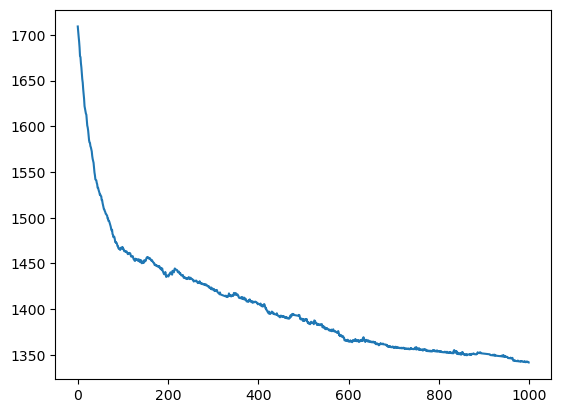

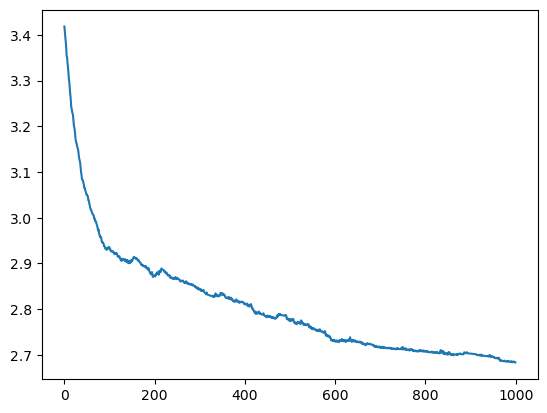

In [17]:
area_sum_lst = [x.sum() for x in area_lst]
area_mean_lst = [x.mean() for x in area_lst]

plt.figure()
plt.plot(area_sum_lst[:-1])
plt.figure()
plt.plot(area_mean_lst[:-1])


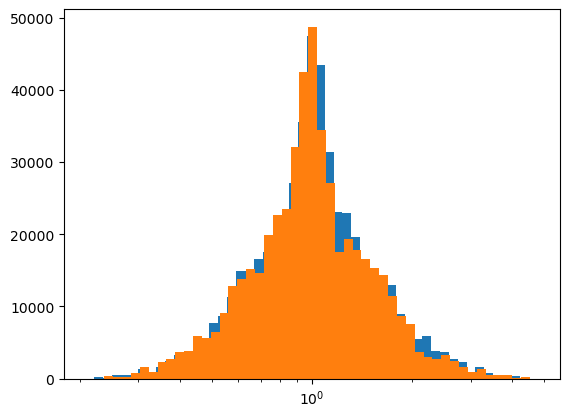

In [29]:
gamma_par_lst = np.concatenate(last_100_dict['gamma_par'])

def plot_loghist(x, bins):
  hist, bins = np.histogram(x, bins=bins)
  logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
  plt.hist(x, bins=logbins)
  plt.xscale('log')
#   plt.yscale('log')

plot_loghist(gamma_par_lst, bins=50)

gamma_perp_lst = np.concatenate(last_100_dict['gamma_perp'])

def plot_loghist(x, bins):
  hist, bins = np.histogram(x, bins=bins)
  logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
  plt.hist(x, bins=logbins)
  plt.xscale('log')
#   plt.yscale('log')

plot_loghist(gamma_perp_lst, bins=50)

In [2]:
data_dict =  np.load("start_conf/data.pkl", allow_pickle=True)

In [5]:
#getting the last values
last_values_dict = {key: value[-1] for key, value in data_dict.items()}

np.save("start_conf/last_values.pkl", last_values_dict, allow_pickle=True)

In [10]:
last_values_dict['alpha_perp']

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [3]:
import torch


def cell_areas(
    dx: torch.Tensor,          # (N, m, 3) normalized neighbor directions
    d: torch.Tensor,           # (N, m) neighbor distances
    p: torch.Tensor,           # (N, 3) apicobasal normal (unit)
    q: torch.Tensor,           # (N, 3) PCP direction (unit, tangent)
    neighbor_mask: torch.Tensor # (N, m) True = invalid neighbor
):
    N, m, _ = dx.shape
    device = dx.device
    eps = 1e-8

    t1 = q                                                # (N, 3)
    t2 = torch.cross(p, q, dim=1)                         # (N, 3)
    t2 = t2 / (torch.norm(t2, dim=1, keepdim=True) + eps)

    r = dx * d[..., None]                                 # (N, m, 3)

    x = torch.einsum("nmk,nk->nm", r, t1)                  # (N, m)
    y = torch.einsum("nmk,nk->nm", r, t2)                  # (N, m)

    angles = torch.atan2(y, x)                            # (N, m)
    angles = angles.masked_fill(neighbor_mask, float("inf"))

    order = torch.argsort(angles, dim=1)                  # (N, m)

    x = torch.gather(x, 1, order)
    y = torch.gather(y, 1, order)
    valid = ~torch.gather(neighbor_mask, 1, order)        # (N, m)

    x_next = torch.roll(x, shifts=-1, dims=1)
    y_next = torch.roll(y, shifts=-1, dims=1)
    valid_next = torch.roll(valid, shifts=-1, dims=1)

    edge_valid = valid & valid_next

    cross = (x * y_next - x_next * y) * edge_valid        # (N, m)
    cross_sum = cross.sum(dim=1)                           # (N,)

    k = valid.sum(dim=1)                                   # (N,)
    has_polygon = k >= 3

    last = (k - 1).clamp(min=0)                            # (N,)
    idx = torch.arange(N, device=device)

    x_last = x[idx, last]
    y_last = y[idx, last]
    x_first = x[idx, 0]
    y_first = y[idx, 0]

    closing = x_last * y_first - x_first * y_last
    closing = closing * has_polygon                        # zero if <3 neighbors

    A_dual = 0.5 * torch.abs(cross_sum + closing)

    # Convert dual area → Voronoi-like area
    A = A_dual / 3.0

    return A

In [4]:
def cell_areas(dx, d, p, q, neighbor_mask):
    # tangent basis
    t1 = q
    t2 = torch.cross(p, q, dim=1)
    t2 = t2 / (torch.norm(t2, dim=1, keepdim=True) + 1e-8)

    # displacements
    r = dx * d[..., None]

    # project
    x = torch.einsum('nmk,nk->nm', r, t1)
    y = torch.einsum('nmk,nk->nm', r, t2)

    # mask invalid neighbors
    large = 1e6
    x = x.masked_fill(neighbor_mask, large)
    y = y.masked_fill(neighbor_mask, large)

    # angles and ordering
    angles = torch.atan2(y, x)
    order = torch.argsort(angles, dim=1)

    x = torch.gather(x, 1, order)
    y = torch.gather(y, 1, order)
    valid = ~neighbor_mask.gather(1, order)

    # shoelace
    x_next = torch.roll(x, -1, dims=1)
    y_next = torch.roll(y, -1, dims=1)
    cross = (x * y_next - x_next * y) * valid

    A_dual = 0.5 * torch.abs(cross.sum(dim=1))
    return A_dual / 3.0

In [5]:
import numpy as np
from scipy.optimize import brentq

d0 = 5*np.log(5) / 4

def d0_i(a, b, xmax=None):
    """
    Compute the x that minimizes
    f(x) = exp(-a x) - exp(-a x/5) + exp(-b x) - exp(-b x/5)

    Parameters
    ----------
    a, b : positive floats
    xmax : optional float, upper search bound

    Returns
    -------
    x0 : float
        Location of the unique minimum
    """

    a = 1/a
    b = 1/b
    
    if a <= 0 or b <= 0:
        raise ValueError("a and b must be positive")

    def df(x):
        return (
            -a * np.exp(-a * x) + (a / 5) * np.exp(-a * x / 5)
            -b * np.exp(-b * x) + (b / 5) * np.exp(-b * x / 5)
        )

    # f'(0) < 0 always
    x_lo = 0.0

    # Sensible upper bound if none provided
    if xmax is None:
        xmax = 10.0 / min(a, b)

    x_hi = xmax

    # Expand upper bound until sign change is guaranteed
    while df(x_hi) < 0:
        x_hi *= 2
        if x_hi > 1e6:
            raise RuntimeError("Failed to bracket root")

    return brentq(df, x_lo, x_hi)

def d0_mean(a, b):
    return d0 * (a + b) / 2 

def d0_geomean(a, b):
    return d0 * np.sqrt(a * b) 


In [6]:
print(d0_mean(1.0, 2))

print(d0_i(1.0, 2))
print(d0_geomean(1.0, 2))

3.017696085813938
2.7396883074265945
2.845111154452183


In [7]:
tens = torch.tensor([[1,1,1,1],[2,2,2,2],[3,3,3,3]])
tens = tens[:,:,None].expand(3,4,3)
trans_tens = torch.transpose_copy(tens, 0,1)
print(tens[0])
print(trans_tens[0])
# print((trans_tens + tens) /2)

tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]])
tensor([[1, 1, 1],
        [2, 2, 2],
        [3, 3, 3]])


In [8]:
data = np.load('moar_gamma_cos_2/data.pkl', allow_pickle=True)

FileNotFoundError: [Errno 2] No such file or directory: 'moar_gamma_cos_2/data.pkl'

In [ ]:
x = data['x']

print(x[-1])

[[nan nan nan]
 [nan nan nan]
 [nan nan nan]
 ...
 [nan nan nan]
 [nan nan nan]
 [nan nan nan]]


In [ ]:
dot = torch.abs(torch.einsum('ijk,ijk->ij', dx, qi,)) # Shape: [n_cells, max_neighbors]


In [ ]:
elongated = self.elongatable[:,None] & self.elongatable[idx]

dot = torch.abs(torch.einsum('ijk,ijk->ij', dx, elonq,)) # Shape: [n_cells, max_neighbors]
angle = torch.arccos(dot)/np.pi

scaled_angle = 2 * angle                                 # 1 when parallel, 0 when perpendicular
elon_factor = 1. - (1 - 2.*scaled_angle) * gammas
elon_factor = torch.where(elongated,  elon_factor, torch.tensor(1.0))[:,:,None]

d_tilde = (d[:,:,None] * elon_factor).squeeze(2)
    



In [ ]:
def find_knn_torch_unchuncked(self, x, k=100):
    with torch.no_grad():
        dists = torch.cdist(x, x)
        knn_indices = dists.topk(k + 1, largest=False).indices[:, 1:]
        knn_dists = dists[torch.arange(dists.shape[0])[:, None], knn_indices]
        return knn_dists, knn_indices

    with torch.no_grad():
        z_mask = torch.tensor(d < 4.5, dtype = bool, device = self.device)


In [ ]:
lst = [1, 2, np.array([3,4]), 1, np.array([5,6,7,8])]

lst_copy = lst.copy()
first_elem = lst_copy.pop(0)
lst_copy.append(first_elem)

print(lst_copy)
print(lst)

[2, array([3, 4]), 1, array([5, 6, 7, 8]), 1]
[1, 2, array([3, 4]), 1, array([5, 6, 7, 8])]


In [ ]:
lst_copy = lst.copy()
lst_copy = lst_copy[1:] + [lst_copy[0]]

print(lst_copy)

[2, array([3, 4]), 1, array([5, 6, 7, 8]), 1]
